# Part 4 — The ARIMA Family

**PyTimeSeries user guide** · *pt.ARIMA and pt.AutoARIMA under the same contract.*

> Uses the `pytimeseries` package on the shared commodity-price dataset.

In [1]:
import warnings; warnings.simplefilter("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pytimeseries as pt
plt.rcParams.update({"figure.figsize": (10, 3.8), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

# Shared dataset: 356 months of global commodity prices (1992-2021)
raw = pd.read_csv("monthly_price.csv")
dates = pd.to_datetime(raw["YEAR"].astype(str) + "-" + raw["MONTH"], format="%Y-%b")
df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]); df.index = dates
df.index.name = "date"; df = df.asfreq("MS")
y = df["Food_Price_Index"]
print("pytimeseries", pt.__version__, "| series:", list(df.columns))

pytimeseries 0.5.0 | series: ['Urea_Price', 'MP_Price', 'TSP_Price', 'Maize_Price', 'Rice_Price', 'Wheat_Price', 'Food_Price_Index', 'Energy_Price_Index', 'VIX_Index']


In [2]:
cv = pt.ExpandingWindow(h=12, n_splits=5)
auto = pt.AutoARIMA(seasonal=False).fit(y)
print('AutoARIMA selected order:', auto.order_)

AutoARIMA selected order: (1, 1, 0)


In [3]:
res = pt.evaluate(pt.ARIMA(order=(1,1,1)), y, cv=cv, metrics=('MASE','RMSE'), sp=12)
res.summary

metric,MASE,RMSE
model,,
Drift,0.7496,7.3852
Naive,0.7579,7.4806
ARIMA,0.7861,7.6711
SeasonalNaive(sp=12),0.9055,8.8899


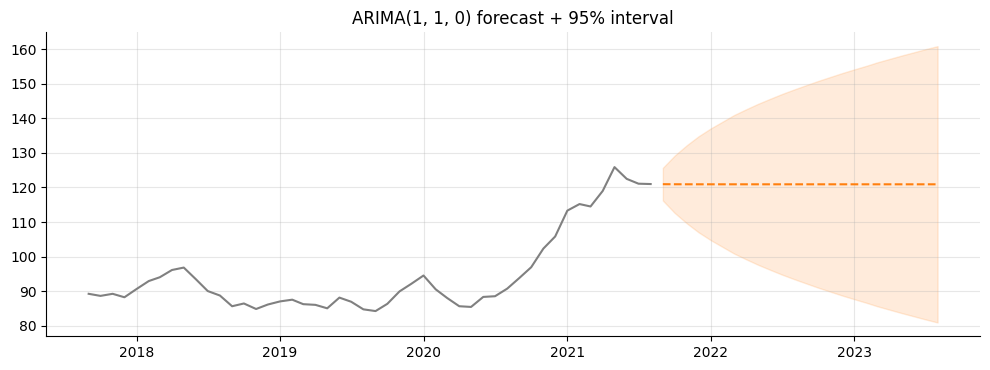

In [4]:
pi = pt.ARIMA(order=auto.order_).fit(y).predict_interval(24, level=[0.8, 0.95])
fig, ax = plt.subplots()
ax.plot(y.index[-48:], y.iloc[-48:], color='0.5')
ax.plot(pi.index, pi['median'], 'C1--')
ax.fill_between(pi.index, pi['0.95_lower'], pi['0.95_upper'], color='C1', alpha=.15)
ax.set_title(f'ARIMA{auto.order_} forecast + 95% interval'); plt.tight_layout(); plt.show()

**Takeaway.** ARIMA/AutoARIMA share the exact `fit/predict/predict_interval` API of ETS — swapping model families is a one-line change.